In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
statlog_shuttle = fetch_ucirepo(id=148) 
  
# data (as pandas dataframes) 
X = statlog_shuttle.data.features 
y = statlog_shuttle.data.targets # variável alvo

In [32]:
# Normalizando os dados
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

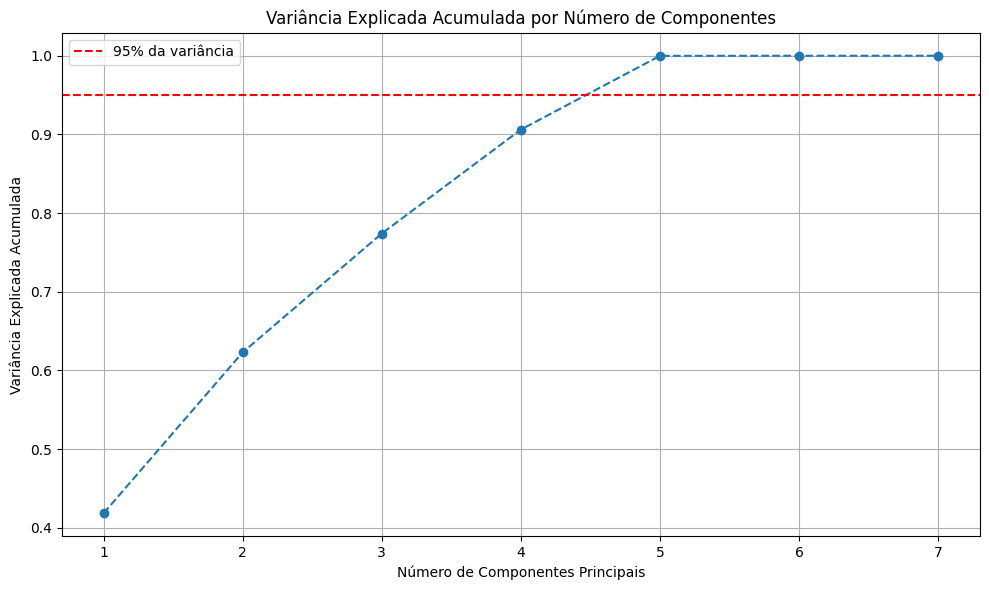

Número de componentes principais mantidos: 5


In [33]:
pca_full = PCA()
pca_full.fit(X_normalized)

# Plotando a variância explicada acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         pca_full.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Variância Explicada Acumulada por Número de Componentes')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% da variância')
plt.legend()
plt.tight_layout()
plt.show()

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_normalized)

print(f"Número de componentes principais mantidos: {pca.n_components_}")

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
from sklearn.base import accuracy_score
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        'hidden_layer_sizes': [
                                (50,), (100,),        # uma camada
                                (50, 50), (100, 50)   # duas camadas
                              ],
        'activation': ['logistic', 'relu', 'tanh'],
        'learning_rate_init': [0.001, 0.01],
        'max_iter': [200, 300],
        'solver': ['adam']  # adam ignora batch_size
    },
    {
        'hidden_layer_sizes': [(50,), (100,)],
        'activation': ['logistic', 'relu', 'tanh'],
        'learning_rate_init': [0.001, 0.01],
        'max_iter': [200, 300],
        'solver': ['sgd'],
        'batch_size': [64, 128]
    }
]

# Criando o GridSearchCV
mlp = MLPClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=3, 
    scoring='accuracy',
    verbose=2,
    n_jobs=-1  # usa todos os núcleos disponíveis
)

# Rodando a busca
grid_search.fit(X_train, y_train.values.ravel())

# Resultados
print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

print(f"\nMelhor acurácia média na validação cruzada: {grid_search.best_score_:.4f}")

# Avaliação no conjunto de teste
y_pred = grid_search.best_estimator_.predict(X_test)
acc_test = accuracy_score(y_test, y_pred)
print(f"Acurácia no conjunto de teste: {acc_test:.4f}")

# DataFrame com todos os resultados
df_results = pd.DataFrame(grid_search.cv_results_)
df_results = df_results.sort_values(by='mean_test_score', ascending=False)
print("\nTop 10 combinações:")
print(df_results[['params', 'mean_test_score']].head(10))

Fitting 3 folds for each of 96 candidates, totalling 288 fits
Melhores parâmetros encontrados:
{'activation': 'tanh', 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.001, 'max_iter': 200, 'solver': 'adam'}

Melhor acurácia média na validação cruzada: 0.9981
Acurácia no conjunto de teste: 0.9983

Top 10 combinações:
                                               params  mean_test_score
40  {'activation': 'tanh', 'hidden_layer_sizes': (...         0.998128
41  {'activation': 'tanh', 'hidden_layer_sizes': (...         0.998128
24  {'activation': 'relu', 'hidden_layer_sizes': (...         0.998054
25  {'activation': 'relu', 'hidden_layer_sizes': (...         0.998054
6   {'activation': 'logistic', 'hidden_layer_sizes...         0.998054
7   {'activation': 'logistic', 'hidden_layer_sizes...         0.998054
23  {'activation': 'relu', 'hidden_layer_sizes': (...         0.997931
22  {'activation': 'relu', 'hidden_layer_sizes': (...         0.997931
3   {'activation': 'logistic', 'hidd

In [36]:
# Extraindo os parâmetros do dicionário 'params'
df_results['hidden_layer_sizes'] = df_results['params'].apply(lambda x: x.get('hidden_layer_sizes'))
df_results['activation'] = df_results['params'].apply(lambda x: x.get('activation'))
df_results['solver'] = df_results['params'].apply(lambda x: x.get('solver'))
df_results['learning_rate_init'] = df_results['params'].apply(lambda x: x.get('learning_rate_init'))
df_results['max_iter'] = df_results['params'].apply(lambda x: x.get('max_iter'))
df_results['batch_size'] = df_results['params'].apply(lambda x: x.get('batch_size', None))
df_results['learning_rate'] = df_results['params'].apply(lambda x: x.get('learning_rate', None))

# Renomear coluna de score
df_results.rename(columns={'mean_test_score': 'accuracy'}, inplace=True)

# Converter tupla para string para melhor visualização
df_results['hidden_str'] = df_results['hidden_layer_sizes'].astype(str)

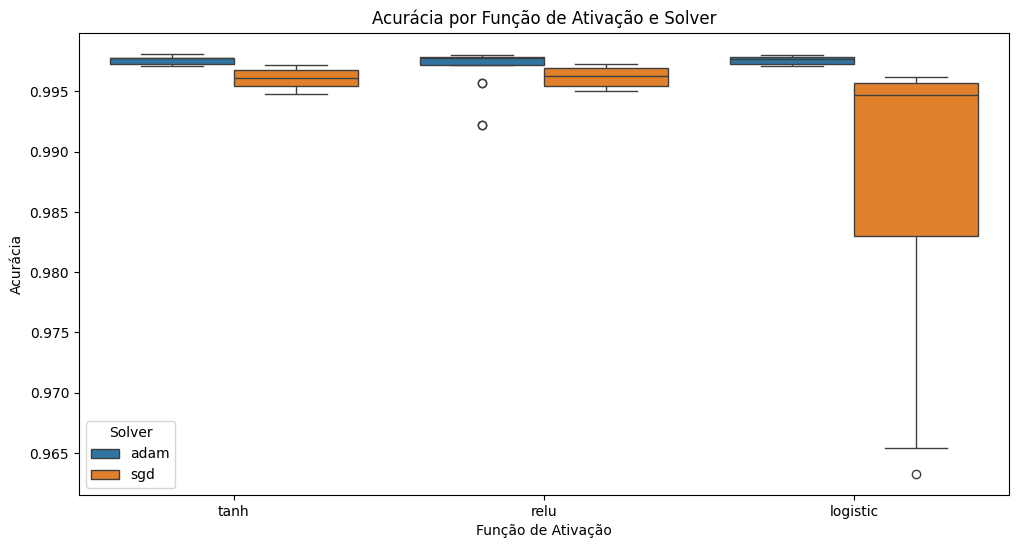

In [37]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_results, x='activation', y='accuracy', hue='solver')
plt.title('Acurácia por Função de Ativação e Solver')
plt.xlabel('Função de Ativação')
plt.ylabel('Acurácia')
plt.legend(title='Solver')
plt.show()

C:\Users\laisa\AppData\Local\Temp\ipykernel_16808\3867805167.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df_results, x='hidden_str', y='accuracy', estimator='mean', ci='sd')


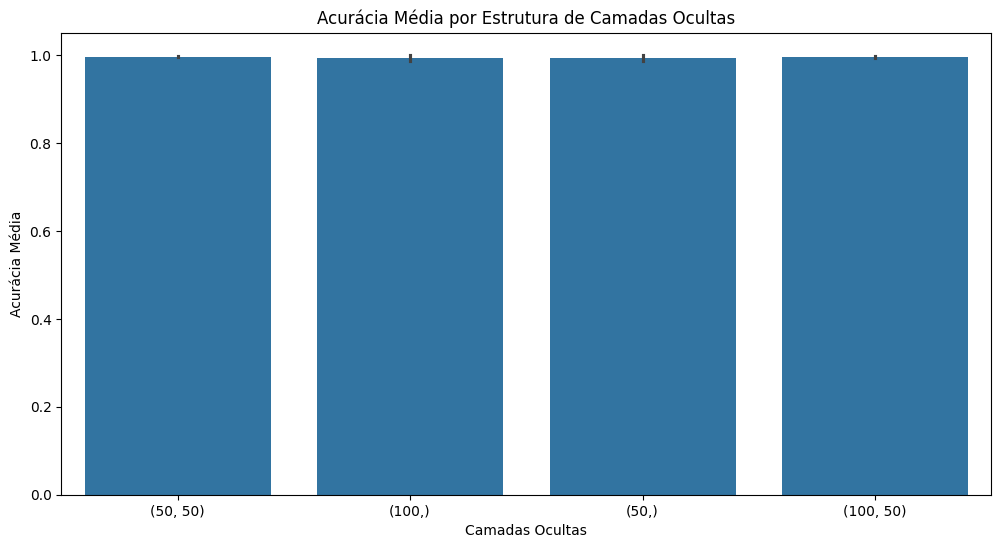

In [38]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x='hidden_str', y='accuracy', estimator='mean', ci='sd')
plt.title('Acurácia Média por Estrutura de Camadas Ocultas')
plt.xlabel('Camadas Ocultas')
plt.ylabel('Acurácia Média')
plt.show()

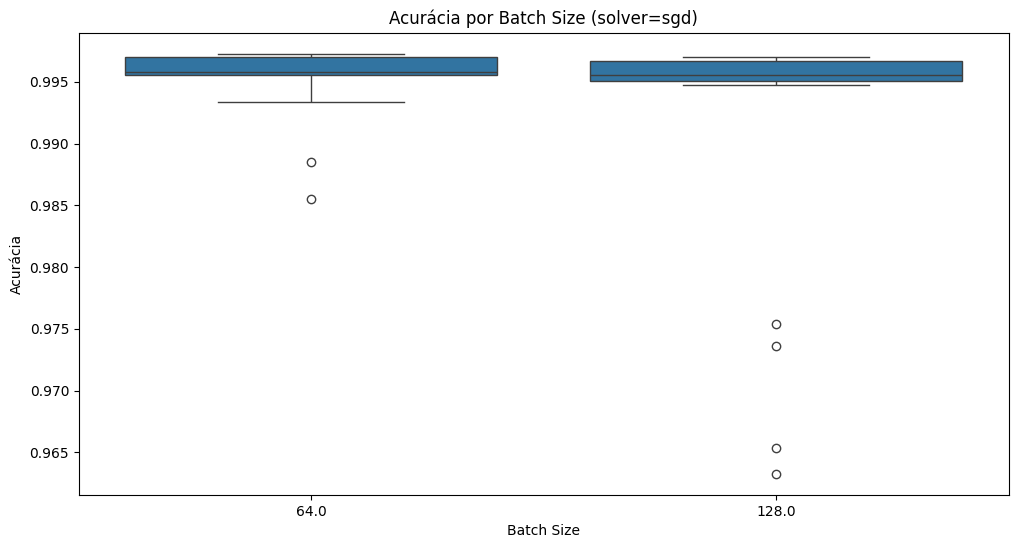

In [40]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_results[df_results['solver'] == 'sgd'],
    x='batch_size',
    y='accuracy'
)
plt.title('Acurácia por Batch Size (solver=sgd)')
plt.xlabel('Batch Size')
plt.ylabel('Acurácia')
plt.show()

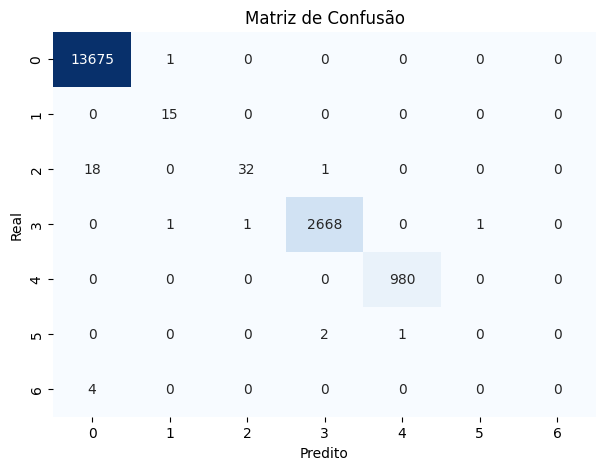

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

In [43]:
import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report_dict).transpose()

# Opcional: arredondar valores para 3 casas decimais
df_report = df_report.round(3)

print("Relatório de Classificação:")
display(df_report)

Relatório de Classificação:


,precision,recall,f1-score,support
1,0.998,1.000,0.999,13676.000
2,0.882,1.000,0.938,15.000
3,0.970,0.627,0.762,51.000
4,0.999,0.999,0.999,2671.000
5,0.999,1.000,0.999,980.000
6,0.000,0.000,0.000,3.000
7,0.000,0.000,0.000,4.000
accuracy,0.998,0.998,0.998,0.998
macro avg,0.693,0.661,0.671,17400.000
weighted avg,0.998,0.998,0.998,17400.000
